In [1]:
%cd /app

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from IPython.display import display

from source_estimation_pinn.environment import CellType, WindField, OccupancyGrid
from dispersion_physics.gas import GasSource, GasDispersion

/app


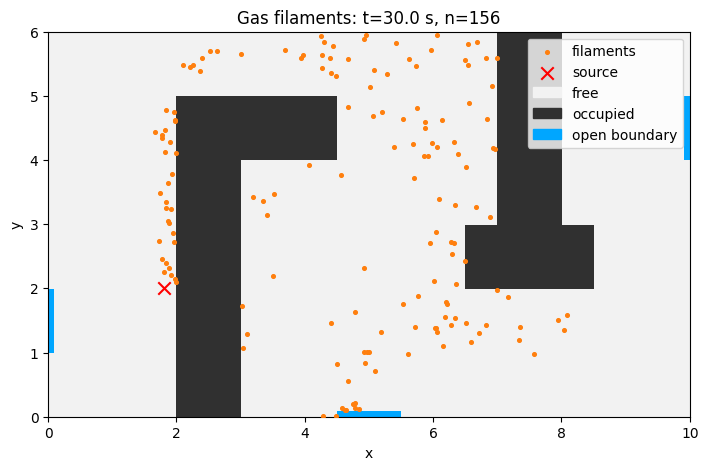

In [2]:


wind = WindField.from_csv("/app/data/example_labyrinth/wind_gt.csv")
occupancy = OccupancyGrid.from_msh_file(
    "/app/data/example_labyrinth/labyrinth_2d_fine.msh",
    resolution=0.1,
)
source = GasSource(
    position=np.array([1.8, 2.0]),
    rate=1.0,
    sigma=0.1,
)
gas = GasDispersion(
    wind_field=wind,
    occupancy=occupancy,
    source=source,
    filaments_per_sec=20.0,
    diffusion_speed_std=0.7,
    initial_sigma=0.05,
    diffusivity=1e-2,
    max_age=30.0,
)

height, width = gas.occupancy.occupancy.shape
x_min, y_min = gas.occupancy.origin
extent = [
    x_min,
    x_min + width * gas.occupancy.resolution,
    y_min,
    y_min + height * gas.occupancy.resolution,
]
occupancy_cmap = ListedColormap(["#303030", "#f2f2f2", "#00a6ff"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(
    gas.occupancy.occupancy,
    origin="lower",
    extent=extent,
    cmap=occupancy_cmap,
    vmin=-0.5,
    vmax=2.5,
    interpolation="nearest",
    zorder=0,
)
particles = ax.scatter(
    [], [], s=7, color="tab:orange", label="filaments", zorder=3
)
source_marker = ax.scatter(
    *gas.source.position,
    marker="x",
    s=80,
    color="red",
    label="source",
    zorder=4,
)
ax.set(
    xlim=(extent[0], extent[1]),
    ylim=(extent[2], extent[3]),
    xlabel="x",
    ylabel="y",
    aspect="equal",
)
ax.legend(handles=[
    particles,
    source_marker,
    Patch(color=occupancy_cmap(CellType.FREE), label="free"),
    Patch(color=occupancy_cmap(CellType.OCCUPIED), label="occupied"),
    Patch(
        color=occupancy_cmap(CellType.OPEN_BOUNDARY),
        label="open boundary",
    ),
])

dt = 0.05
display_handle = display(fig, display_id=True)

for step in range(600):
    gas.step(dt)
    particles.set_offsets(gas.positions)
    ax.set_title(
        f"Gas filaments: t={gas.time:.1f} s, n={gas.number_of_filaments}"
    )

    # Updating every fifth step keeps inline notebooks responsive.
    if step % 5 == 0:
        display_handle.update(fig)

display_handle.update(fig)
plt.close(fig)